
## Gradient Boosting

Similar to Bagging (Ensemble approaches), Gradient Boosting is applied on top of another machine learning algorithm.

1. A "weak" machine learning model i.e. typically a decision tree.
2. "strong" machine learning model, which is composed of multiple weak models.

---

In gradient boosting, at each step, a new weak model is trained to predict the "error" of the current strong model (which is called the pseudo response).

Let's assume "error" is the difference between the prediction and a regressive label.


The weak model (that is, the prediction of "error") is then added to the strong model with a negative sign to reduce the error of the strong model.






Gradient boosting is iterative. Each iteration invokes the following formula:

$$F_{i+1} = F_i - f_i$$


$F_i$ is the strong model at step i

$f_i$ is the weak model at step

---

This operation repeats until a stopping criterion is met,
such as
* a maximum number of iterations
* Strong model begins to overfit as measured on a separate validation dataset
* logloss/error criteria is met

In [ ]:
# Simplified example of regressive gradient boosting (From https://developers.google.com/machine-learning/decision-forests/intro-to-gbdt)

y = ... # the labels
x = ... # the features

strong_model = []
strong_predictions = np.zeros_like(y) # Initially, the strong model is empty.

for i in range(num_iters):

    # Error of the strong model
    error = strong_predictions - y

    # The weak model is a decision tree (see CART chapter)
    # without pruning and a maximum depth of 3.
    weak_model = tfdf.keras.CartModel(
        task=tfdf.keras.Task.REGRESSION,
        validation_ratio=0.0,
        max_depth=3)
    weak_model.fit(x=x, y=error)

    strong_model.append(weak_model)

    weak_predictions = weak_model.predict(x)[:,0]

    strong_predictions = strong_predictions - weak_predictions

    ## with shrinkage
    shrinkage = 0.1
    strong_predictions = strong_predictions - shrinkage * weak_predictions


### Shrinkage
In real world practice, the weak model is multiplied by a small value
(for example, $v=0.1$) before adding in the strong model.

* This small value is called the shrinkage.

This means that each iteration used the following formula:

Each iteration uses the following formula:
$$F_{i+1} = F_i - v * f_i$$

* Shrinkage in gradient boosting is analogous to learning rate in neural networks.
Shrinkage controls how fast the strong model is learning, which helps limit overfitting.
* That is, a shrinkage value closer to 0.0 reduces overfitting more than a shrinkage value closer to 1.0.

---

## Error Term
#### MSE (Mean Squared Error)

In regression problem, we generally use a Mean Squared error as a term for identifying error in a model

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2
$$

Here,
$(n)$ is the number of observations,
$(Y_i)$ represents the actual values, and
$(\hat{Y}_i)$ represents the predicted values.




### What is Log-Loss?

* Log-loss, also known as logarithmic loss or cross-entropy loss, is a performance metric used in classification tasks to evaluate how well a model's predicted probabilities match the actual class labels.



* Log-loss measures the accuracy of a classifier by comparing the predicted probabilities to the actual class labels. It penalizes incorrect predictions, especially those that are confident but wrong. The goal is to minimize the log-loss, with a perfect model achieving a log-loss of 0.



* For a binary classification problem, the log-loss is calculated as:

$$
\text{Log-loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
$$

Where:
- $( N )$ is the number of samples.
- $(y_i)$ is the actual label (0 or 1) for the \( i \)-th sample.
- $(p_i)$ is the predicted probability of the sample being in class 1.

#### Interpretation

- **Low Log-Loss**: Indicates that the predicted probabilities are close to the actual labels.
- **High Log-Loss**: Indicates that the predicted probabilities are far from the actual labels, especially if the model is confidently wrong.

##### Example

Consider a binary classification problem where we predict whether a patient has a certain disease (1) or not (0). If the model predicts a probability of 0.9 for a patient having the disease, but the patient does not have the disease (actual label is 0), the log-loss will be high, reflecting the confident but incorrect prediction.

##### Why Use Log-Loss?

Log-loss is particularly useful because it provides a continuous measure of performance that is sensitive to the confidence of predictions. It encourages models to produce well-calibrated probability estimates rather than just correct classifications.


### Overfitting, regularization, and early stopping

Unlike random forests, gradient boosted trees can overfit. Therefore, as for neural networks, you can apply regularization and early stopping using a validation dataset.

For example, the following figures show loss and accuracy curves for training and validation sets when training a GBT model. Notice how divergent the curves are, which suggests a high degree of overfitting.

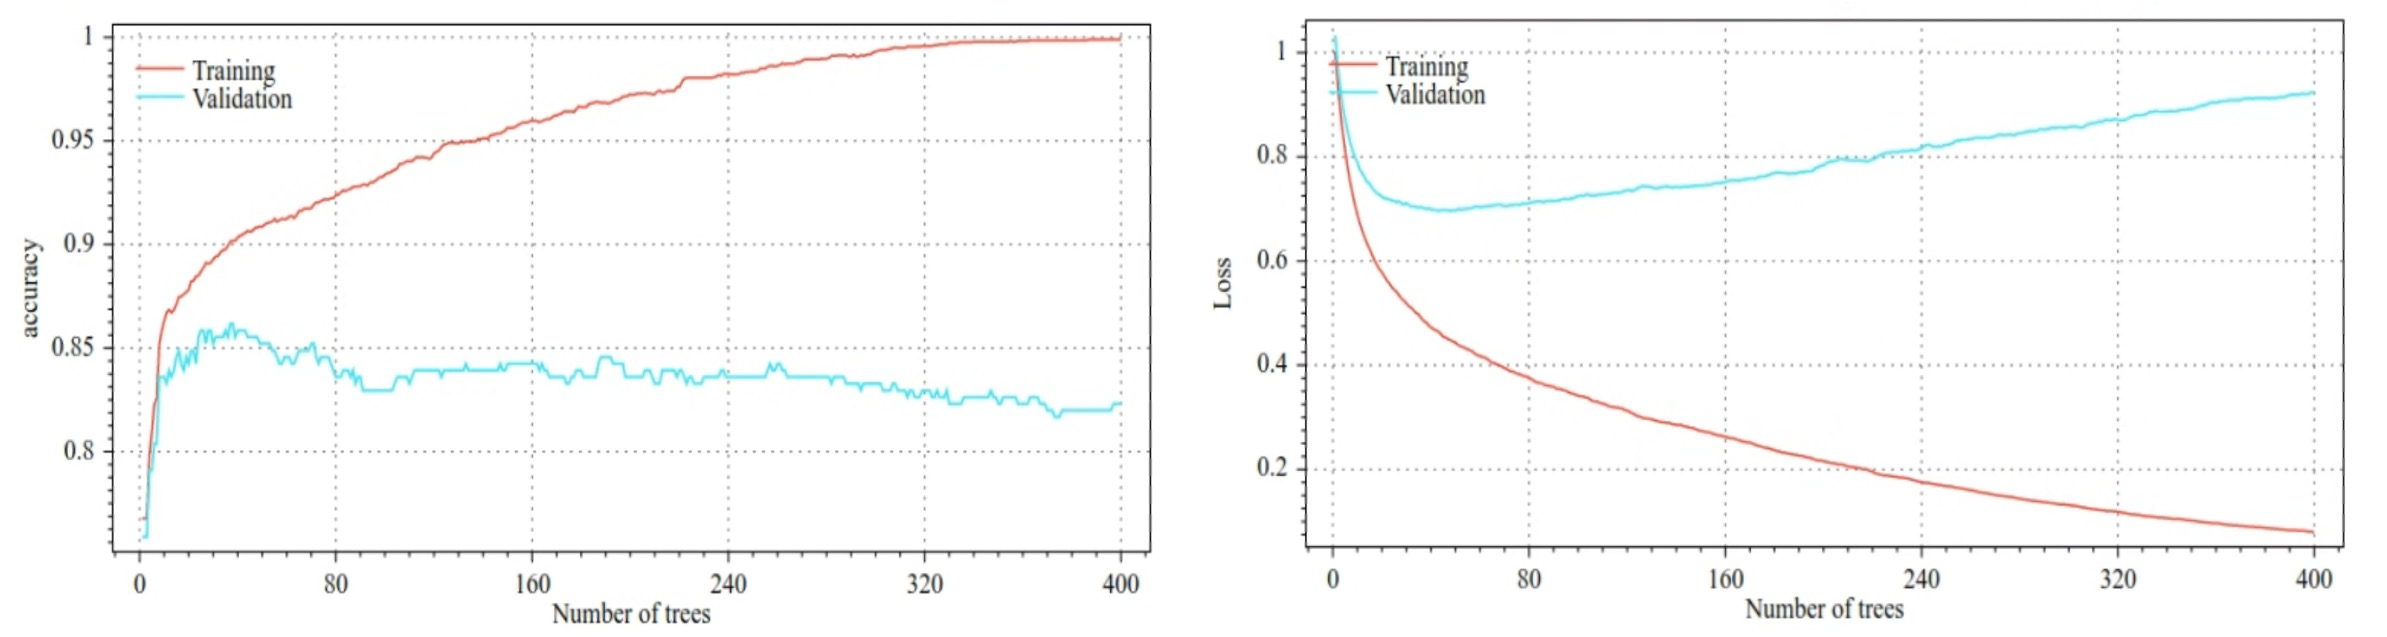

### Practical Implementation of Gradient Boosted Algorithms

In [ ]:
## install packges
!pip install wurlitzer
!pip install ydf ## Install YDF
!pip install xgboost-cpu ## Install XgBoost
!pip install lightgbm ## Install Light GBM
!pip install catboost ## Install CatBoost
!pip install dask[dataframe]

In [ ]:
## Import sklearn metrics and dataset
import sklearn.metrics
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
## load and prepare Breast Cancer Dataset
## load data as dataframe

breast_cancer_data = load_breast_cancer(as_frame=True)
breast_cancer_data

{'data':      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0          17.99         10.38          122.80     1001.0          0.11840   
 1          20.57         17.77          132.90     1326.0          0.08474   
 2          19.69         21.25          130.00     1203.0          0.10960   
 3          11.42         20.38           77.58      386.1          0.14250   
 4          20.29         14.34          135.10     1297.0          0.10030   
 ..           ...           ...             ...        ...              ...   
 564        21.56         22.39          142.00     1479.0          0.11100   
 565        20.13         28.25          131.20     1261.0          0.09780   
 566        16.60         28.08          108.30      858.1          0.08455   
 567        20.60         29.33          140.10     1265.0          0.11780   
 568         7.76         24.54           47.92      181.0          0.05263   
 
      mean compactness  mean concavity  me

In [ ]:
## Extract dataframe from the dataset
breast_cancer_df = breast_cancer_data.frame
breast_cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
breast_cancer_df.shape,breast_cancer_df['target'].value_counts()

((569, 31),
 target
 1    357
 0    212
 Name: count, dtype: int64)

In [ ]:
## split the dataframe in to train and test sample
Train_df,Test_df = train_test_split(breast_cancer_df,test_size=0.2, stratify= breast_cancer_df['target'],random_state=94)

In [ ]:
Train_df.shape, Train_df['target'].value_counts()

((455, 31),
 target
 1    285
 0    170
 Name: count, dtype: int64)

In [ ]:
Test_df.shape, Test_df['target'].value_counts()

((114, 31),
 target
 1    72
 0    42
 Name: count, dtype: int64)

In [ ]:
## For XgBoost, LightGBM and CatBoost, separate the target variable from the train and test df
train_df_wo_target = Train_df.drop(columns=['target'])
test_df_wo_target = Test_df.drop(columns=['target'])
train_target = Train_df['target']
test_target = Test_df['target']

In [ ]:
train_df_wo_target.head(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
27,18.61,20.25,122.1,1094.0,0.0944,0.1066,0.1490,0.07731,0.1697,0.05699,...,21.31,27.26,139.9,1403.0,0.1338,0.2117,0.3446,0.1490,0.2341,0.07421
131,15.46,19.48,101.7,748.9,0.1092,0.1223,0.1466,0.08087,0.1931,0.05796,...,19.26,26.00,124.9,1156.0,0.1546,0.2394,0.3791,0.1514,0.2837,0.08019


In [ ]:
train_target.head(2)

,target
27,0
131,0


### XgBoost

In [ ]:
import xgboost as xgb

## Define XgBoost classifier with default optiopns
clf_xgboost = xgb.XGBClassifier()


# Fit the model
clf_xgboost.fit(train_df_wo_target, train_target)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
print(f'Accuracy: {clf_xgboost.score(test_df_wo_target, test_target)}')
print(f'ROC AUC: {sklearn.metrics.roc_auc_score(test_target, clf_xgboost.predict_proba(test_df_wo_target)[:,1])}')

Accuracy: 0.9736842105263158
ROC AUC: 0.996362433862434


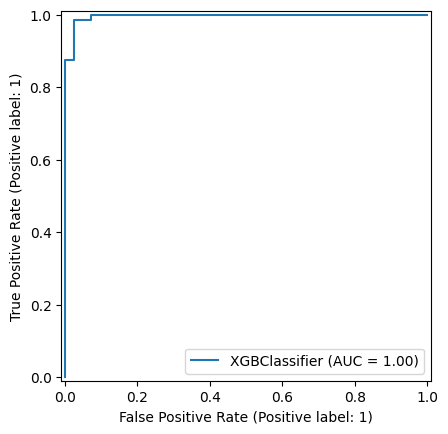

In [ ]:
sklearn.metrics.RocCurveDisplay.from_estimator(clf_xgboost, test_df_wo_target, test_target)

### Light GBM - Light Gradient Boosted Model

In [ ]:
# import Light GBM
import lightgbm as lgb

## Define Light GBM Classifier
clf_lgb = lgb.sklearn.LGBMClassifier()

# Fit the model,
clf_lgb.fit(train_df_wo_target, train_target)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000394 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMClassifier()

In [ ]:
print(f'Accuracy: {clf_lgb.score(test_df_wo_target, test_target)}')
print(f'ROC AUC: {sklearn.metrics.roc_auc_score(test_target, clf_lgb.predict_proba(test_df_wo_target)[:,1])}')

Accuracy: 0.9649122807017544
ROC AUC: 0.9970238095238095


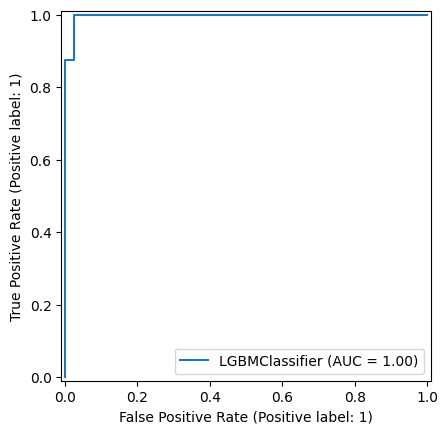

In [ ]:
sklearn.metrics.RocCurveDisplay.from_estimator(clf_lgb, test_df_wo_target, test_target)

### YDF Gradient Boosted Trees

In [ ]:
## import YDF
import ydf
Train_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
27,18.610,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,...,27.26,139.90,1403.0,0.1338,0.2117,0.34460,0.14900,0.2341,0.07421,0
131,15.460,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,0.05796,...,26.00,124.90,1156.0,0.1546,0.2394,0.37910,0.15140,0.2837,0.08019,0
273,9.742,15.67,61.50,289.9,0.09037,0.04689,0.01103,0.01407,0.2081,0.06312,...,20.88,68.09,355.2,0.1467,0.0937,0.04043,0.05159,0.2841,0.08175,1
24,16.650,21.38,110.00,904.6,0.11210,0.14570,0.15250,0.09170,0.1995,0.06330,...,31.56,177.00,2215.0,0.1805,0.3578,0.46950,0.20950,0.3613,0.09564,0
558,14.590,22.68,96.39,657.1,0.08473,0.13300,0.10290,0.03736,0.1454,0.06147,...,27.27,105.90,733.5,0.1026,0.3171,0.36620,0.11050,0.2258,0.08004,1


In [ ]:
## define and train YDF model
clf_ydf = ydf.GradientBoostedTreesLearner(label='target').train(Train_df)

Train model on 455 examples
Model trained in 0:00:01.681904


In [ ]:
## Evaluated YDF Model
clf_ydf.evaluate(Test_df)

Label \ Pred,0,1
0,40,1
1,2,71


### CatBoost

In [ ]:
##
import catboost as cb

## Define CatBoost Classifier
clf_catboost = cb.CatBoostClassifier()

# Fit the model
clf_catboost.fit(train_df_wo_target, train_target)

Learning rate set to 0.00736
0:	learn: 0.6809081	total: 12.7ms	remaining: 12.6s
1:	learn: 0.6691870	total: 21.3ms	remaining: 10.6s
2:	learn: 0.6575553	total: 29.8ms	remaining: 9.92s
3:	learn: 0.6464676	total: 40.3ms	remaining: 10s
4:	learn: 0.6350377	total: 49.1ms	remaining: 9.78s
5:	learn: 0.6258551	total: 57.4ms	remaining: 9.51s
6:	learn: 0.6137169	total: 65.3ms	remaining: 9.26s
7:	learn: 0.6027421	total: 73.5ms	remaining: 9.12s
8:	learn: 0.5910794	total: 81.7ms	remaining: 9s
9:	learn: 0.5822873	total: 89.8ms	remaining: 8.89s
10:	learn: 0.5730745	total: 99.9ms	remaining: 8.98s
11:	learn: 0.5633614	total: 108ms	remaining: 8.9s
12:	learn: 0.5532182	total: 125ms	remaining: 9.5s
13:	learn: 0.5441259	total: 134ms	remaining: 9.43s
14:	learn: 0.5359318	total: 143ms	remaining: 9.36s
15:	learn: 0.5278353	total: 151ms	remaining: 9.28s
16:	learn: 0.5208114	total: 160ms	remaining: 9.22s
17:	learn: 0.5129371	total: 172ms	remaining: 9.38s
18:	learn: 0.5058715	total: 181ms	remaining: 9.32s
19:	lear

In [ ]:
print(f'Accuracy: {clf_catboost.score(test_df_wo_target, test_target)}')
print(f'ROC AUC: {sklearn.metrics.roc_auc_score(test_target, clf_catboost.predict_proba(test_df_wo_target)[:,1])}')

Accuracy: 0.9649122807017544
ROC AUC: 0.9966931216931217


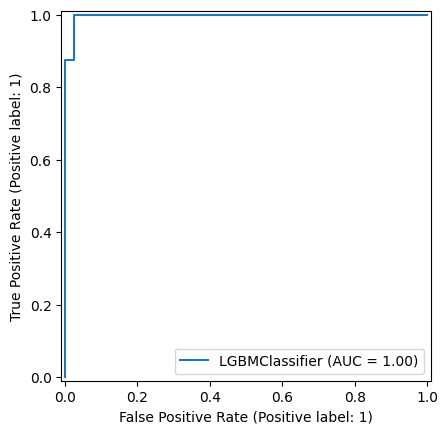

In [ ]:
sklearn.metrics.RocCurveDisplay.from_estimator(clf_lgb, test_df_wo_target, test_target)

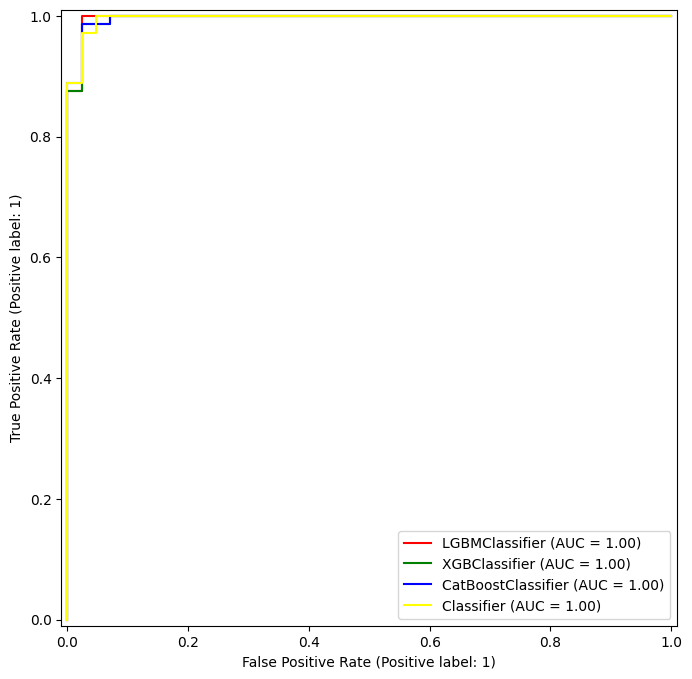

In [ ]:
##
import matplotlib.pyplot as plt
import sklearn
fig,ax = plt.subplots(figsize=(8,8))

sklearn.metrics.RocCurveDisplay.from_estimator(clf_lgb, test_df_wo_target, test_target,ax=ax,color='red')
sklearn.metrics.RocCurveDisplay.from_estimator(clf_xgboost, test_df_wo_target, test_target,ax=ax,color='green')
sklearn.metrics.RocCurveDisplay.from_estimator(clf_catboost, test_df_wo_target, test_target,ax=ax,color='blue')
sklearn.metrics.RocCurveDisplay.from_predictions(test_target, clf_ydf.predict(Test_df),ax=ax,color='yellow')


The Roc-AUC curve above are for light gradiant boost classifier, XGBoost classifier, YDF- gradeint boosted trees classifier, and Catboost classifier. All model performed very well in differentiation, proceeding with any of the model would give great results in implementation. Project's python notebook is attached.